# Wind Speed and Gust as Indicators of Changing Weather

**Client:** A Malaysian public weather information service  
**Project aim:** Identify which weather indicators are most useful for communicating outdoor comfort, UV risk, rainfall conditions, and changing weather patterns to the public.  
**Research question:** *How closely are wind speed and gust related, and can sudden increases in gust strength signal unstable or changing weather conditions?*

This notebook answers the question from a **client-facing** perspective. The goal is not only to describe the data, but also to decide whether `wind_speed` and `gust` are useful variables for **public weather guidance**.


## 1. Introduction, Variables, and Analysis Plan

**Why this question matters**

For the public, gusty wind often feels like a warning that the weather is becoming unstable. If that belief is supported by the data, the client could use gust-related language in public guidance. If not, gust should be treated as a secondary indicator rather than a standalone warning signal.

**Variables used**

| Variable | Role in the analysis | Why it matters |
|---|---|---|
| `wind_speed` | Primary variable | Represents average wind conditions |
| `gust` | Primary variable | Captures short-lived peaks in wind strength |
| `precipitation_rate` | Supporting variable | Used as a proxy for wet-weather conditions |
| `pressure` | Supporting variable | Helps assess whether stronger gust behaviour aligns with broader weather changes |
| `state`, `hour`, `timestamp` | Context variables | Used to compare patterns across place and time |

**Derived indicators**

- `gust_diff = gust - wind_speed`: shows how much stronger a gust is than the average wind
- `gust_factor = gust / wind_speed` for observations where `wind_speed > 0`: measures relative gustiness or turbulence
- `wet_weather`: defined as `precipitation_rate > 0`

**Analysis plan**

1. Prepare and clean the subset of data needed for the wind analysis.
2. Measure how closely `wind_speed` and `gust` move together.
3. Examine the size and pattern of gust strength using `gust_diff` and `gust_factor`.
4. Test whether stronger gust behaviour is associated with wet or changing weather.
5. Translate the results into a recommendation for the client.


In [1]:
import os
from pathlib import Path

# Use writable cache directories so plots render cleanly in the local environment.
Path('/tmp/mplconfig').mkdir(parents=True, exist_ok=True)
Path('/tmp/xdg-cache').mkdir(parents=True, exist_ok=True)
os.environ['MPLCONFIGDIR'] = '/tmp/mplconfig'
os.environ['XDG_CACHE_HOME'] = '/tmp/xdg-cache'

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from IPython.display import display

sns.set_theme(style='whitegrid', palette='deep')
plt.rcParams['figure.figsize'] = (9, 5)
plt.rcParams['axes.titlesize'] = 13
plt.rcParams['axes.labelsize'] = 11
pd.set_option('display.max_columns', None)
pd.set_option('display.float_format', lambda x: f'{x:,.3f}')

ROOT = Path.cwd()
DATA_PATH = ROOT / 'data' / 'malaysia_weather_data.csv'
MONTH_ORDER = ['Jan', 'Feb', 'Mar', 'Apr', 'May', 'Jun', 'Jul', 'Aug', 'Sep', 'Oct', 'Nov', 'Dec']
MONTH_MAP = {month: index for index, month in enumerate(MONTH_ORDER, start=1)}

print(f'Data path: {DATA_PATH}')

Data path: /Users/c2/Library/CloudStorage/GoogleDrive-zche0400@student.monash.edu/My Drive/ADS1001/project/MWF-G2/data/malaysia_weather_data.csv


In [2]:
def prepare_weather_subset(path: Path) -> pd.DataFrame:
    """Load the project dataset and prepare the wind-focused analysis table."""
    df = pd.read_csv(path)

    cols = [
        'place', 'city', 'state', 'pressure', 'humidity', 'wind_speed', 'gust',
        'precipitation_rate', 'temperature', 'year', 'month', 'day', 'hour',
        'minutes', 'seconds'
    ]
    weather = df[cols].copy()
    weather['month_num'] = weather['month'].map(MONTH_MAP)
    weather['timestamp'] = pd.to_datetime(
        dict(
            year=weather['year'],
            month=weather['month_num'],
            day=weather['day'],
            hour=weather['hour'],
            minute=weather['minutes'],
            second=weather['seconds'],
        ),
        errors='coerce'
    )

    weather = weather.dropna(subset=['wind_speed', 'gust', 'timestamp']).copy()
    weather = weather[(weather['wind_speed'] >= 0) & (weather['gust'] >= 0)].copy()

    weather['wet_weather'] = weather['precipitation_rate'].fillna(0) > 0
    weather['gust_diff'] = weather['gust'] - weather['wind_speed']
    weather['gust_factor'] = np.where(weather['wind_speed'] > 0, weather['gust'] / weather['wind_speed'], np.nan)
    weather['high_gust'] = weather['gust'] >= weather['gust'].quantile(0.9)
    weather['high_gust_factor'] = weather['gust_factor'] >= weather['gust_factor'].quantile(0.9)

    return weather

raw_df = pd.read_csv(DATA_PATH)
analysis_df = prepare_weather_subset(DATA_PATH)

missing_summary = raw_df[['wind_speed', 'gust', 'pressure', 'precipitation_rate']].isna().sum().rename('missing_count').to_frame()

print(f'Original rows: {len(raw_df):,}')
print(f'Rows kept for wind/gust analysis: {len(analysis_df):,}')
print(f'Share of original rows kept: {len(analysis_df) / len(raw_df):.1%}')
print()
print('Missing values in key variables before cleaning:')
display(missing_summary)
print('Preview of the prepared analysis table:')
display(analysis_df.head())

Original rows: 57,475
Rows kept for wind/gust analysis: 44,191
Share of original rows kept: 76.9%

Missing values in key variables before cleaning:


,missing_count
wind_speed,8642
gust,13284
pressure,8190
precipitation_rate,10901


Preview of the prepared analysis table:


,place,city,state,pressure,humidity,wind_speed,gust,precipitation_rate,temperature,year,month,day,hour,minutes,seconds,month_num,timestamp,wet_weather,gust_diff,gust_factor,high_gust,high_gust_factor
0,Bandar Sri Permaisuri,Kuala Lumpur,Kuala Lumpur,"1,015.325",73.700,0.900,1.500,0.000,30.300,2022,Sep,23,13,54,57,9,2022-09-23 13:54:57,False,0.600,1.667,False,False
1,Ampang Jaya,Kuala Lumpur,Kuala Lumpur,"1,000.680",92.000,5.200,5.300,0.000,27.000,2023,May,4,19,9,59,5,2023-05-04 19:09:59,False,0.100,1.019,False,False
2,Bukit Jalil,Kuala Lumpur,Kuala Lumpur,"1,013.550",99.000,0.000,0.000,0.000,26.400,2021,Oct,23,23,44,43,10,2021-10-23 23:44:43,False,0.000,NaN,False,False
3,Bukit Jalil,Kuala Lumpur,Kuala Lumpur,"1,005.420",99.000,0.000,0.000,0.000,31.100,2021,Mar,21,18,9,47,3,2021-03-21 18:09:47,False,0.000,NaN,False,False
4,Penang Road,George Town,Pulau Pinang,"1,007.790",88.000,6.400,16.100,0.000,25.800,2022,Dec,22,7,0,23,12,2022-12-22 07:00:23,False,9.700,2.516,True,False


## 2. Data Cleaning and Feature Engineering

The analysis keeps observations where `wind_speed`, `gust`, and the reconstructed timestamp are available. Negative wind values are also excluded. This ensures that each row can be interpreted consistently in later comparisons.

The notebook creates two gust-related indicators:

- **`gust_diff`** to measure the absolute increase from average wind to peak wind
- **`gust_factor`** to measure the relative jump from average wind to gust

These features are useful because the client does not only need to know whether wind is strong; they need to know whether the wind is **becoming unusually erratic or unstable**.


In [3]:
cleaning_summary = pd.DataFrame({
    'metric': [
        'Rows in raw dataset',
        'Rows after requiring wind_speed, gust, and timestamp',
        'Rows flagged as wet weather',
        'Rows with valid gust_factor',
        'Median wind_speed (m/s)',
        'Median gust (m/s)',
        'Median gust_diff (m/s)',
        'Median gust_factor'
    ],
    'value': [
        len(raw_df),
        len(analysis_df),
        int(analysis_df['wet_weather'].sum()),
        int(analysis_df['gust_factor'].notna().sum()),
        analysis_df['wind_speed'].median(),
        analysis_df['gust'].median(),
        analysis_df['gust_diff'].median(),
        analysis_df['gust_factor'].median(),
    ]
})

display(cleaning_summary)

state_summary = (
    analysis_df.groupby('state')[['wind_speed', 'gust', 'gust_diff', 'gust_factor']]
    .median()
    .round(3)
)
print('Median wind behaviour by state:')
display(state_summary)

,metric,value
0,Rows in raw dataset,"57,475.000"
1,"Rows after requiring wind_speed, gust, and tim...","44,191.000"
2,Rows flagged as wet weather,"2,240.000"
3,Rows with valid gust_factor,"29,207.000"
4,Median wind_speed (m/s),0.800
5,Median gust (m/s),1.600
6,Median gust_diff (m/s),0.600
7,Median gust_factor,1.545


Median wind behaviour by state:


,wind_speed,gust,gust_diff,gust_factor
state,,,,
Kuala Lumpur,0.700,1.400,0.500,1.500
Pulau Pinang,1.100,3.000,1.400,1.680


## 3. Analysis 1: Relationship Between Wind Speed and Gust

The first test is straightforward: if `wind_speed` and `gust` are closely related, they should move together strongly across observations. A strong relationship would mean gust often acts as a sharper version of the same wind pattern, rather than as a completely separate phenomenon.


,metric,value
0,Correlation between wind_speed and gust,0.934
1,Proportion of rows where gust >= wind_speed,1.000
2,Median wind_speed (m/s),0.800
3,Median gust (m/s),1.600


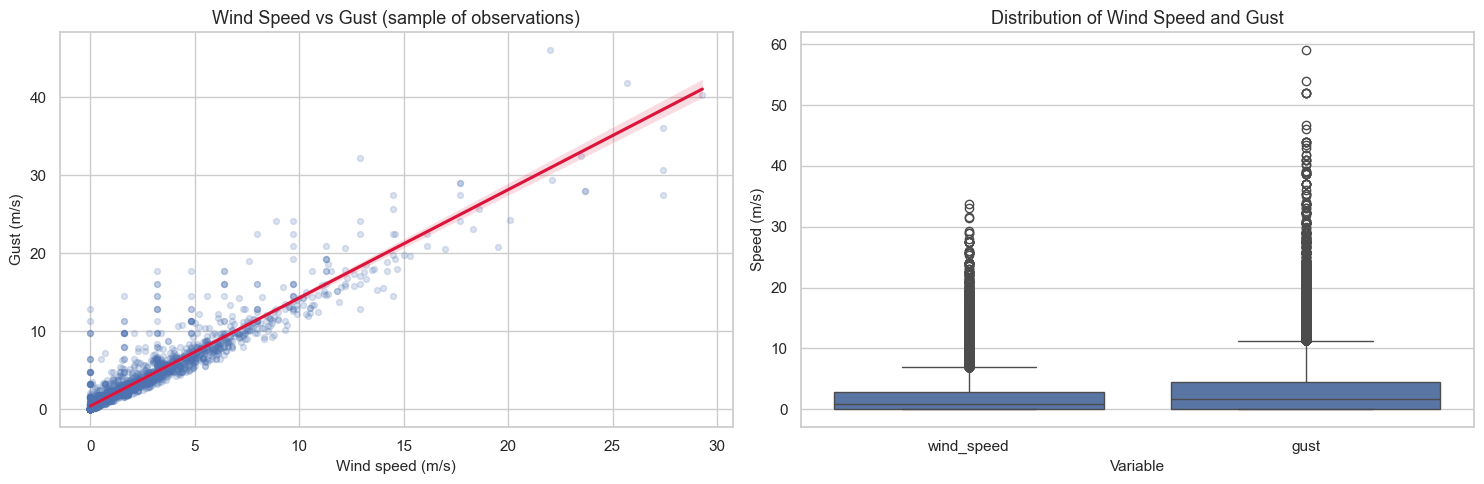

In [4]:
correlation = analysis_df['wind_speed'].corr(analysis_df['gust'])
prop_gust_ge_wind = (analysis_df['gust'] >= analysis_df['wind_speed']).mean()
relationship_summary = pd.DataFrame({
    'metric': [
        'Correlation between wind_speed and gust',
        'Proportion of rows where gust >= wind_speed',
        'Median wind_speed (m/s)',
        'Median gust (m/s)'
    ],
    'value': [
        correlation,
        prop_gust_ge_wind,
        analysis_df['wind_speed'].median(),
        analysis_df['gust'].median()
    ]
})

display(relationship_summary)

sample_df = analysis_df.sample(n=min(3000, len(analysis_df)), random_state=42)

fig, axes = plt.subplots(1, 2, figsize=(15, 5))

sns.regplot(
    data=sample_df,
    x='wind_speed',
    y='gust',
    scatter_kws={'alpha': 0.2, 's': 18},
    line_kws={'color': 'crimson'},
    ax=axes[0]
)
axes[0].set_title('Wind Speed vs Gust (sample of observations)')
axes[0].set_xlabel('Wind speed (m/s)')
axes[0].set_ylabel('Gust (m/s)')

sns.boxplot(
    data=analysis_df[['wind_speed', 'gust']].melt(var_name='variable', value_name='value'),
    x='variable',
    y='value',
    ax=axes[1]
)
axes[1].set_title('Distribution of Wind Speed and Gust')
axes[1].set_xlabel('Variable')
axes[1].set_ylabel('Speed (m/s)')

plt.tight_layout()
plt.show()

### Section Conclusion

`wind_speed` and `gust` are **very closely related** in this dataset. The correlation is approximately **0.93**, which indicates a strong positive relationship. Gust is also greater than or equal to average wind in almost every valid observation.

For the client, this means gust is not a random or isolated measure. It usually reflects the same wind pattern as `wind_speed`, but in a more intense form that may be easier for the public to notice.


## 4. Analysis 2: How Large Are Gust Increases?

A strong correlation alone does not answer whether gusts are useful as an instability signal. The next step is to measure **how much** gust exceeds average wind, and whether that difference is large enough to matter in public communication.

This section uses `gust_diff` and `gust_factor` to show how much stronger gusts typically are than average wind conditions.


,metric,value
0,Median gust_diff (m/s),0.600
1,Mean gust_diff (m/s),1.165
2,Median gust_factor,1.545
3,Mean gust_factor,1.943
4,90th percentile gust_factor,3.000


,hour,wind_speed,gust,gust_factor
0,0,0.100,0.400,1.667
1,1,0.100,0.400,1.643
2,2,0.000,0.200,1.667
3,3,0.000,0.200,1.667
4,4,0.000,0.300,1.596
5,5,0.100,0.300,1.625
6,6,0.000,0.200,1.667
7,7,0.000,0.200,1.687
8,8,0.300,0.800,1.667
9,9,0.800,1.600,1.636


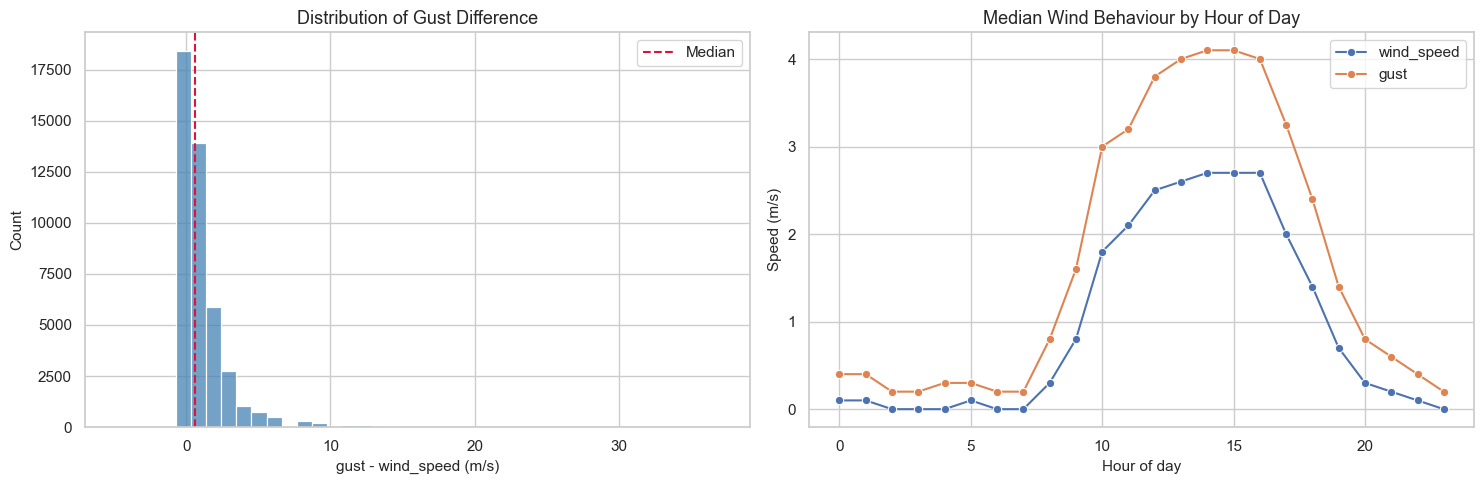

In [5]:
gust_strength_summary = pd.DataFrame({
    'metric': [
        'Median gust_diff (m/s)',
        'Mean gust_diff (m/s)',
        'Median gust_factor',
        'Mean gust_factor',
        '90th percentile gust_factor'
    ],
    'value': [
        analysis_df['gust_diff'].median(),
        analysis_df['gust_diff'].mean(),
        analysis_df['gust_factor'].median(),
        analysis_df['gust_factor'].mean(),
        analysis_df['gust_factor'].quantile(0.9)
    ]
})

display(gust_strength_summary)

hourly_medians = (
    analysis_df.groupby('hour')[['wind_speed', 'gust', 'gust_factor']]
    .median()
    .reset_index()
)

display(hourly_medians)

fig, axes = plt.subplots(1, 2, figsize=(15, 5))

sns.histplot(analysis_df['gust_diff'], bins=40, color='steelblue', ax=axes[0])
axes[0].axvline(analysis_df['gust_diff'].median(), color='crimson', linestyle='--', label='Median')
axes[0].set_title('Distribution of Gust Difference')
axes[0].set_xlabel('gust - wind_speed (m/s)')
axes[0].legend()

sns.lineplot(data=hourly_medians, x='hour', y='wind_speed', marker='o', label='wind_speed', ax=axes[1])
sns.lineplot(data=hourly_medians, x='hour', y='gust', marker='o', label='gust', ax=axes[1])
axes[1].set_title('Median Wind Behaviour by Hour of Day')
axes[1].set_xlabel('Hour of day')
axes[1].set_ylabel('Speed (m/s)')

plt.tight_layout()
plt.show()

### Section Conclusion

The median `gust_diff` is about **0.6 m/s**, while the median `gust_factor` is about **1.55**. In practical terms, this means gust is often about **50% stronger** than the average wind reading when wind is present.

This matters for the client because gust captures the **felt sharpness** of wind conditions. It can help communicate short-lived wind risk better than average wind alone, especially when conditions feel more erratic than a simple mean wind speed suggests.


## 5. Analysis 3: Do Stronger Gusts Align With Wet Weather?

To test whether gust can act as a weather-change signal, this section compares gust behaviour between **dry** and **wet** observations. If gust is a reliable warning sign, wet-weather conditions should show noticeably stronger gust behaviour.


wind_speed         gust        gust_factor         pressure  \
                  mean median  mean median        mean median      mean   
wet_weather                                                               
False            1.969  0.800 3.122  1.600       1.940  1.545 1,010.765   
True             2.213  1.000 3.607  1.800       2.005  1.556 1,010.447   

                      precipitation_rate         
               median               mean median  
wet_weather                                      
False       1,011.180              0.000  0.000  
True        1,010.670              7.142  1.800

,group,wet_weather_rate
0,All observations,0.051
1,Top 10% gust,0.064
2,Top 10% gust_factor,0.060


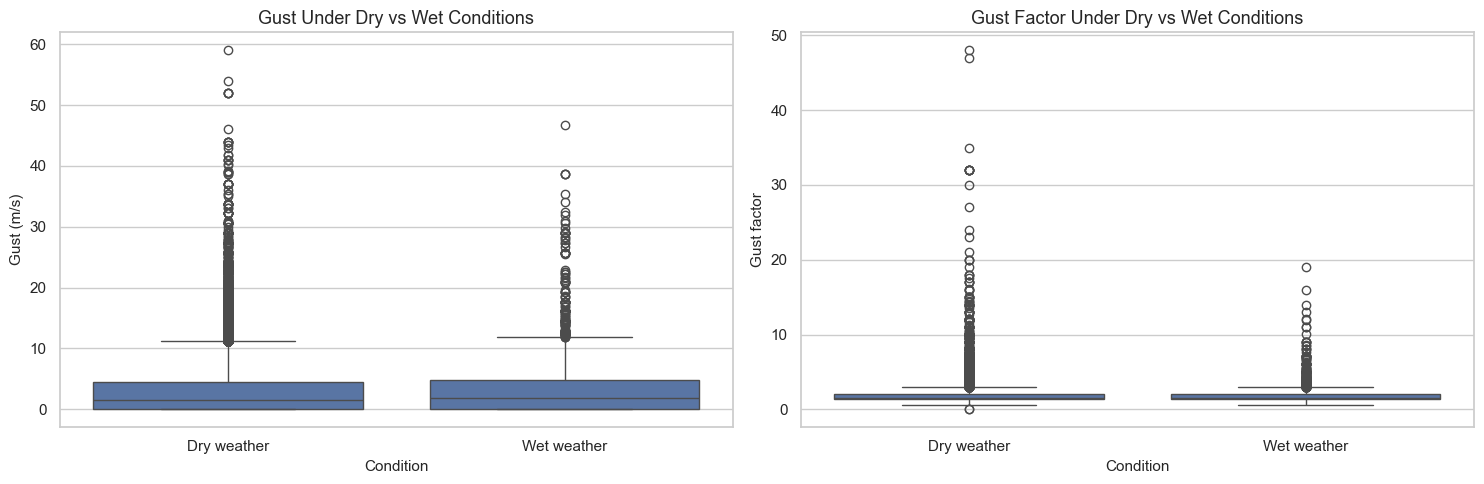

In [6]:
condition_labels = np.where(analysis_df['wet_weather'], 'Wet weather', 'Dry weather')
plot_df = analysis_df.assign(condition=condition_labels)

wet_summary = (
    analysis_df.groupby('wet_weather')[['wind_speed', 'gust', 'gust_factor', 'pressure', 'precipitation_rate']]
    .agg(['mean', 'median'])
    .round(3)
)

top_decile_rates = pd.DataFrame({
    'group': ['All observations', 'Top 10% gust', 'Top 10% gust_factor'],
    'wet_weather_rate': [
        analysis_df['wet_weather'].mean(),
        analysis_df.loc[analysis_df['high_gust'], 'wet_weather'].mean(),
        analysis_df.loc[analysis_df['high_gust_factor'], 'wet_weather'].mean()
    ]
})

display(wet_summary)
display(top_decile_rates)

fig, axes = plt.subplots(1, 2, figsize=(15, 5))

sns.boxplot(data=plot_df, x='condition', y='gust', ax=axes[0])
axes[0].set_title('Gust Under Dry vs Wet Conditions')
axes[0].set_xlabel('Condition')
axes[0].set_ylabel('Gust (m/s)')

sns.boxplot(data=plot_df[plot_df['gust_factor'].notna()], x='condition', y='gust_factor', ax=axes[1])
axes[1].set_title('Gust Factor Under Dry vs Wet Conditions')
axes[1].set_xlabel('Condition')
axes[1].set_ylabel('Gust factor')

plt.tight_layout()
plt.show()

### Section Conclusion

Wet-weather observations do show slightly stronger gust behaviour, but the increase is **modest rather than dramatic**. The wet-weather rate rises from about **4.9%** in the rest of the data to about **6.4%** among the top 10% of gust readings, and to about **6.0%** among the top 10% of gust-factor readings.

For the client, this suggests gust is **not a strong standalone warning of rainfall or weather change**. It contains some useful signal, but the effect is weak enough that gust should be interpreted alongside other indicators rather than used by itself.


## 6. Analysis 4: What Happens Around the Start of Rain?

A stronger test of changing weather is to examine what happens **right before rain begins**. If sudden gust strength is a reliable early signal, there should be a noticeable jump in gust-related measures at rainfall onset.

This section compares each rain-start observation with the most recent earlier observation from the same place, keeping only events where the time gap is at most 180 minutes.


,metric,value
0,Rain-start events kept for analysis,605


,variable,previous_median,rain_start_median,median_change
0,wind_speed,1.100,1.100,0.000
1,gust,1.900,1.900,0.000
2,gust_factor,1.533,1.551,0.018
3,pressure,"1,010.890","1,011.185",0.295


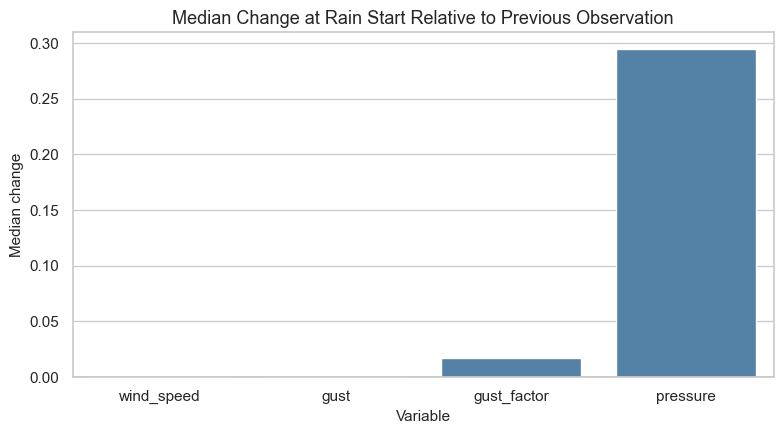

In [7]:
event_df = analysis_df.sort_values(['place', 'timestamp']).copy()

for col in ['wind_speed', 'gust', 'gust_factor', 'pressure']:
    event_df[f'prev_{col}'] = event_df.groupby('place')[col].shift(1)

event_df['prev_wet_weather'] = event_df.groupby('place')['wet_weather'].shift(1).eq(True)
event_df['prev_timestamp'] = event_df.groupby('place')['timestamp'].shift(1)
event_df['gap_min'] = (event_df['timestamp'] - event_df['prev_timestamp']).dt.total_seconds() / 60

event_df['rain_start'] = event_df['wet_weather'] & (~event_df['prev_wet_weather'])
rain_start_df = event_df[event_df['rain_start'] & event_df['gap_min'].le(180)].copy()

rain_start_summary = pd.DataFrame({
    'metric': ['Rain-start events kept for analysis'],
    'value': [len(rain_start_df)]
})

after_vs_before = pd.DataFrame({
    'variable': ['wind_speed', 'gust', 'gust_factor', 'pressure'],
    'previous_median': [
        rain_start_df['prev_wind_speed'].median(),
        rain_start_df['prev_gust'].median(),
        rain_start_df['prev_gust_factor'].median(),
        rain_start_df['prev_pressure'].median(),
    ],
    'rain_start_median': [
        rain_start_df['wind_speed'].median(),
        rain_start_df['gust'].median(),
        rain_start_df['gust_factor'].median(),
        rain_start_df['pressure'].median(),
    ],
})
after_vs_before['median_change'] = after_vs_before['rain_start_median'] - after_vs_before['previous_median']

display(rain_start_summary)
display(after_vs_before.round(3))

plt.figure(figsize=(8, 4.5))
sns.barplot(data=after_vs_before, x='variable', y='median_change', color='steelblue')
plt.axhline(0, color='black', linewidth=1)
plt.title('Median Change at Rain Start Relative to Previous Observation')
plt.xlabel('Variable')
plt.ylabel('Median change')
plt.tight_layout()
plt.show()

### Section Conclusion

Around the start of rainfall, gust-related measures increase only **slightly**. In this sample of rain-start events, the median `gust` and median `gust_factor` are close to their immediately previous values, which means a sudden jump in gust is **not consistently observed before rain begins**.

For the client, this is important: gust can describe wind instability, but it does **not behave like a strong early-warning trigger** for rainfall onset in this dataset.


## 7. Final Answer for the Client

### Main findings

- `wind_speed` and `gust` are **strongly related**, with a correlation of about **0.93**.
- Gust usually represents a **more intense version of the same wind pattern**, rather than a separate weather signal.
- Gust is often materially higher than average wind, so it is useful for describing **short-term wind risk**.
- However, stronger gust behaviour is only **weakly associated** with wet weather and does not show a consistent jump right before rainfall starts.

### Recommendation

For public weather communication, the client should treat **gust as a supporting indicator of unstable wind conditions**, not as a standalone predictor of changing weather or imminent rainfall.

A practical communication strategy would be:

1. Use `wind_speed` to describe the overall wind conditions.
2. Use `gust` to warn the public when winds may feel suddenly stronger or more erratic.
3. Combine gust with rainfall and pressure-related indicators when communicating broader weather change.

### Limitation

This notebook uses observational weather data rather than a forecasting model, so the results support **communication guidance** rather than formal prediction. Stronger predictive claims would require a more explicit event-based forecasting setup.
